# TripMate: a tool-augmented travel-planning agent with LangChain

**PSIS Activity 2: Build a Tool-Augmented / Agentic LLM Application**
Course: Generative AI · Timeline: 16-30 September 2026

TripMate is a conversational agent that plans trips by **calling real external APIs** instead of relying on the
LLM's memory: live weather forecasts, exchange rates, public holidays and Wikivoyage travel-guide content. It
remembers the conversation, handles failed or unexpected tool responses without inventing data, and can turn its
answer into a validated JSON itinerary.

| Notebook section | What it shows |
|---|---|
| 1. Problem and use case | why a travel planner needs tools |
| 2. Setup | install, API key, imports |
| 3. Architecture | components and the LLM-tool loop |
| 4. LangChain components | tools, prompt template, output parser |
| 5. Agent demo | tool calling, memory, structured itinerary |
| 6. Failure handling | outages, empty responses, unknown places |
| 7. Testing and evaluation | offline unit tests + 10 live scenarios |
| 8. Limitations and improvements | critical reflection |

## 1. Problem and use case

Planning a short trip means combining facts that change daily (weather, exchange rates, holidays) with local
knowledge (what to see, how to get around) and some arithmetic (the budget). A plain LLM is weak at all three:

* its knowledge stops at a training cut-off, so it **cannot know next week's forecast or today's exchange rate**;
* asked anyway, it tends to **produce plausible numbers that are not grounded in any source**;
* multi-item budgets are a common place for **arithmetic slips**.

TripMate makes the LLM the *planner and writer* and gives it tools for the facts. Target users are students and
budget travellers planning 1-5 day domestic or international trips, who want one conversation instead of five
browser tabs.

## 2. Setup

In [1]:
# Colab: upload/clone the repository first, then install. Locally: pip install -r requirements.txt
import sys
if "google.colab" in sys.modules:
    %pip install -q -r requirements.txt

In [2]:
import os, json, datetime as dt
from getpass import getpass

# The key is read from the environment or a .env file. It is never stored in this notebook.
from tripmate import config
if not config.api_key():
    os.environ["GEMINI_API_KEY"] = getpass("Gemini API key (https://aistudio.google.com/apikey): ")

from IPython.display import Markdown, Image, display
from tripmate import TripMate, ALL_TOOLS, net
from tripmate.render import turn_to_markdown, plan_to_markdown, tool_trace_lines
from tripmate.prompts import AGENT_SYSTEM_PROMPT

print("model:", config.MODEL_NAME, "| fallback:", config.FALLBACK_MODEL_NAME,
      "| rate limit:", config.REQUESTS_PER_MINUTE, "requests/min")
print("today:", config.today())


def show_json(obj, limit=1200):
    text = json.dumps(obj, indent=2, ensure_ascii=False)
    print(text[:limit] + ("\n..." if len(text) > limit else ""))

model: gemini-3.5-flash | fallback: gemini-3.5-flash-lite | rate limit: 4.0 requests/min
today: 2026-09-17


## 3. Architecture

The agent is built with `langchain.agents.create_agent` (a LangGraph ReAct loop). On every turn Gemini decides which
tools to call; LangGraph executes them and feeds the results back until the model writes a final answer. For trip
plans an LCEL chain then converts the answer into a `TripPlan` JSON object.

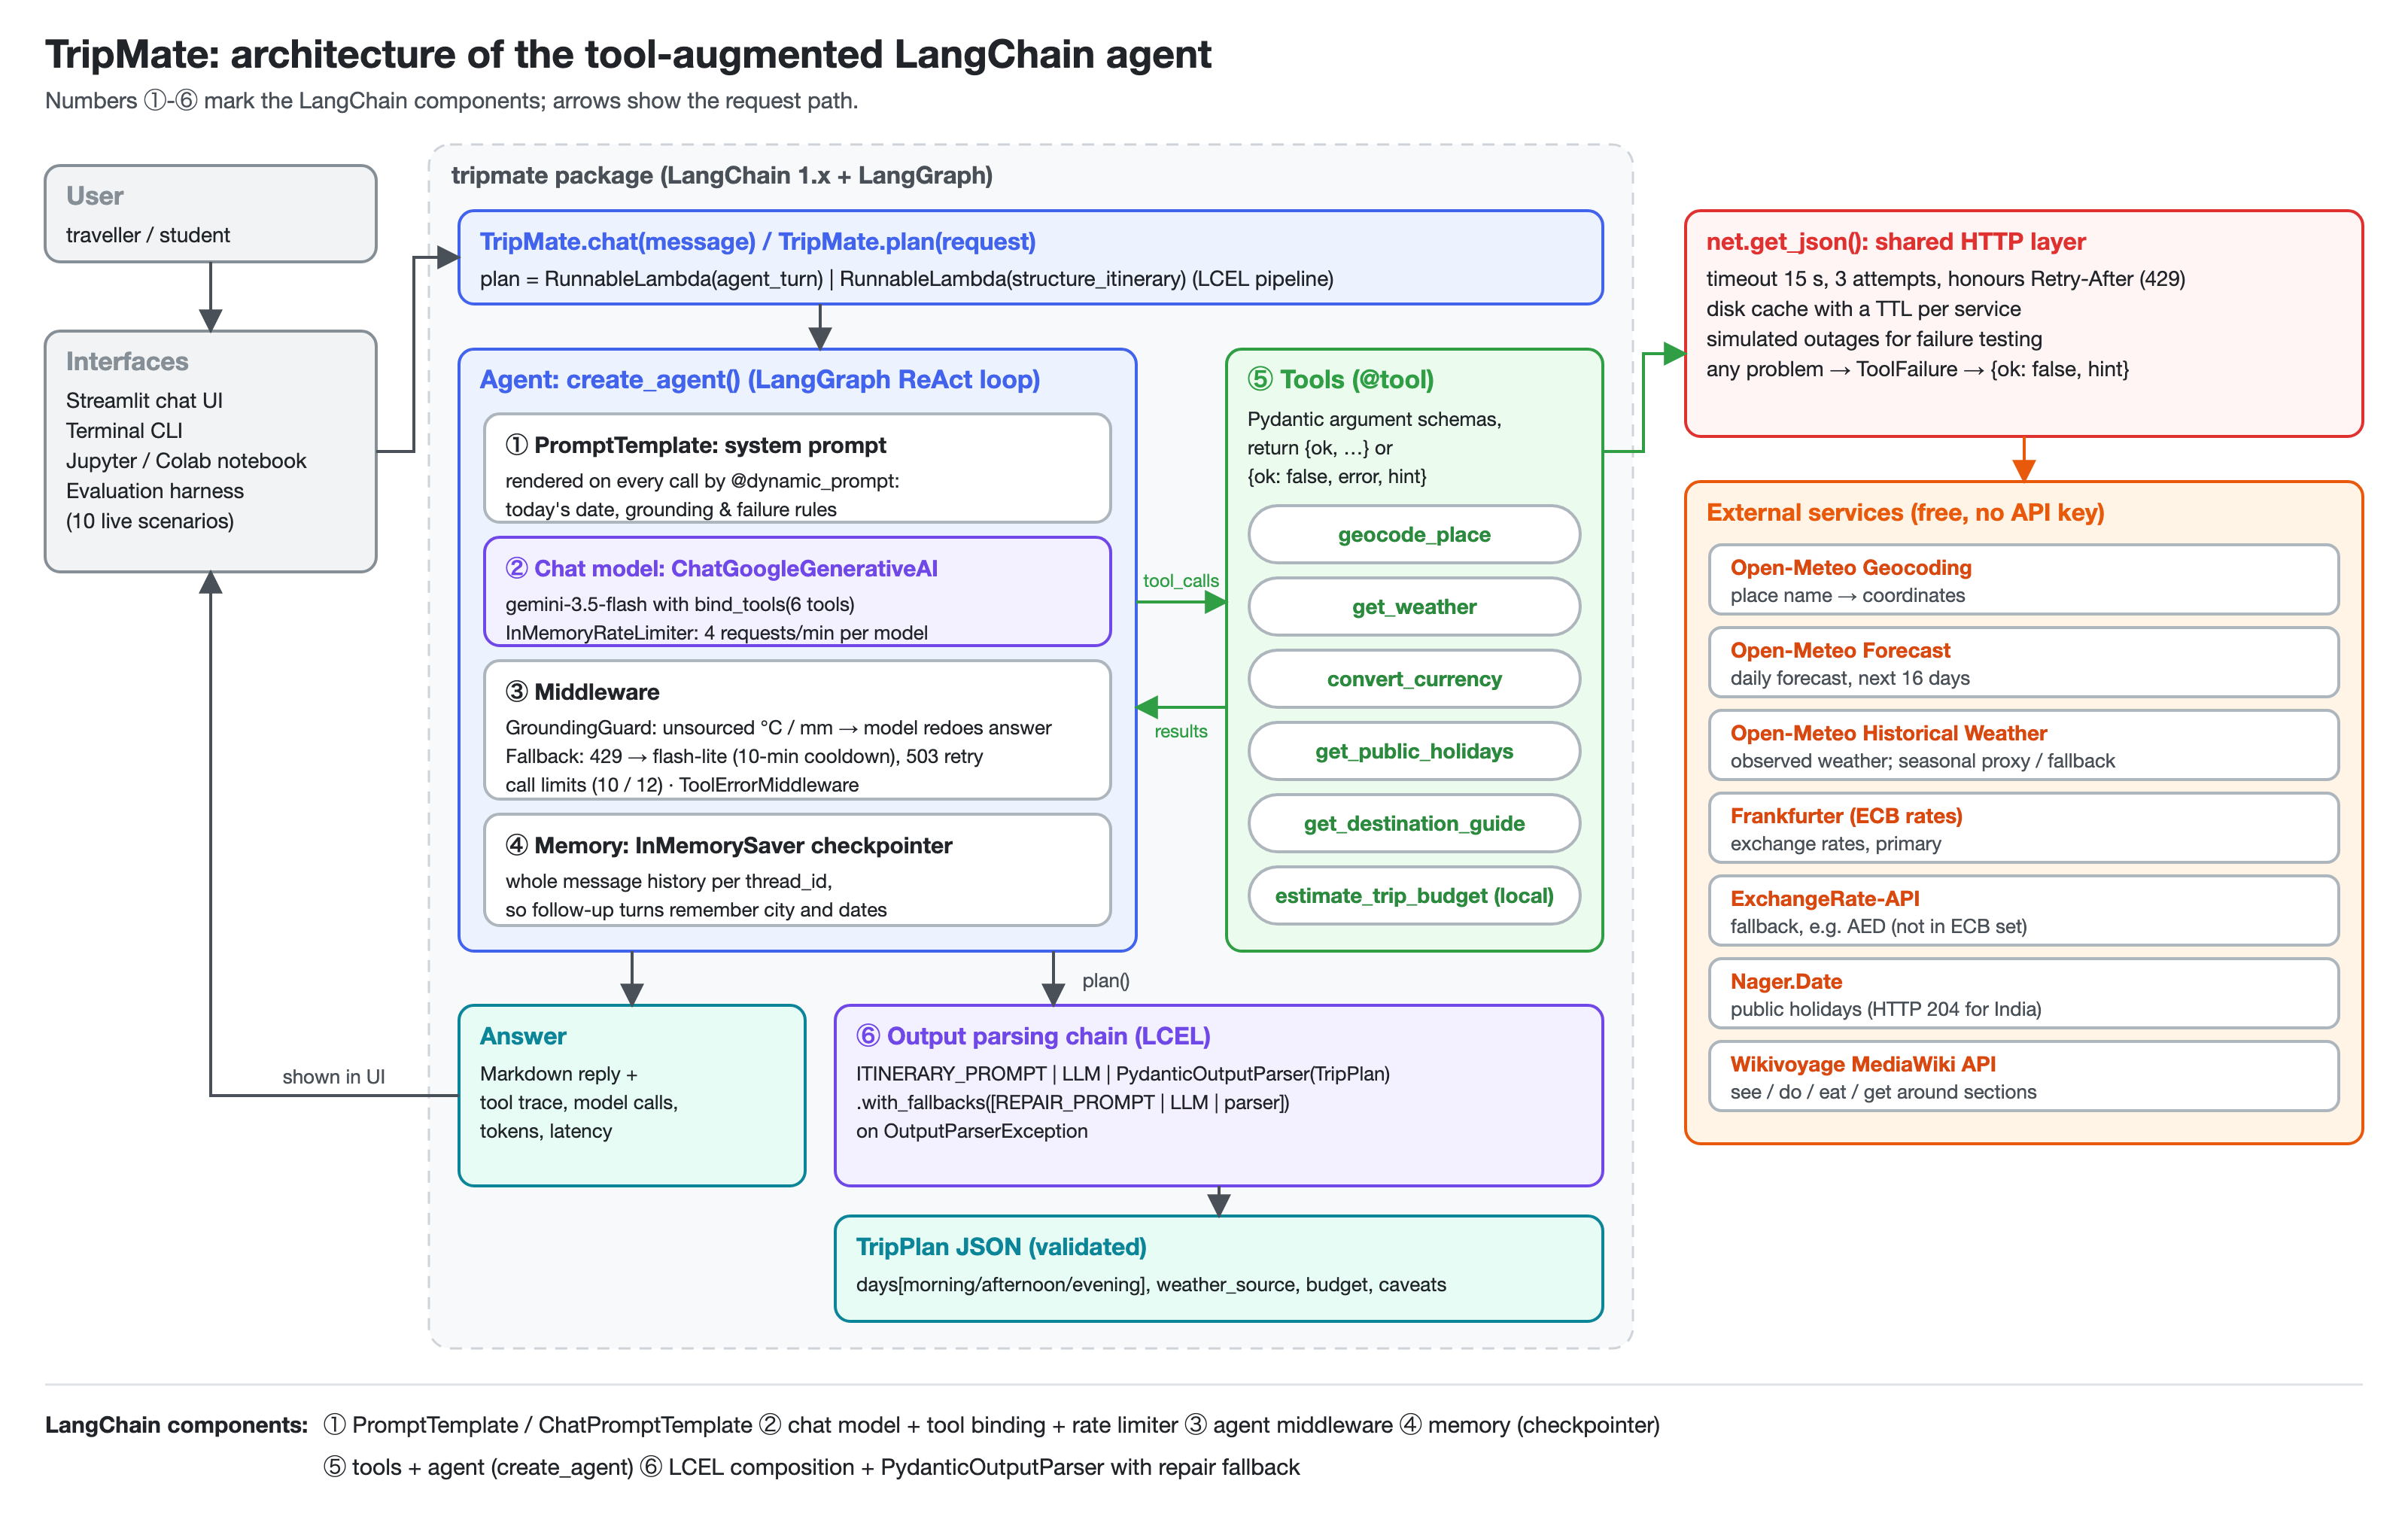

In [3]:
display(Image(filename="docs/architecture.png", width=1100))

**LLM-tool interaction** for a request whose dates are beyond the forecast horizon (scenario S6 in the evaluation):

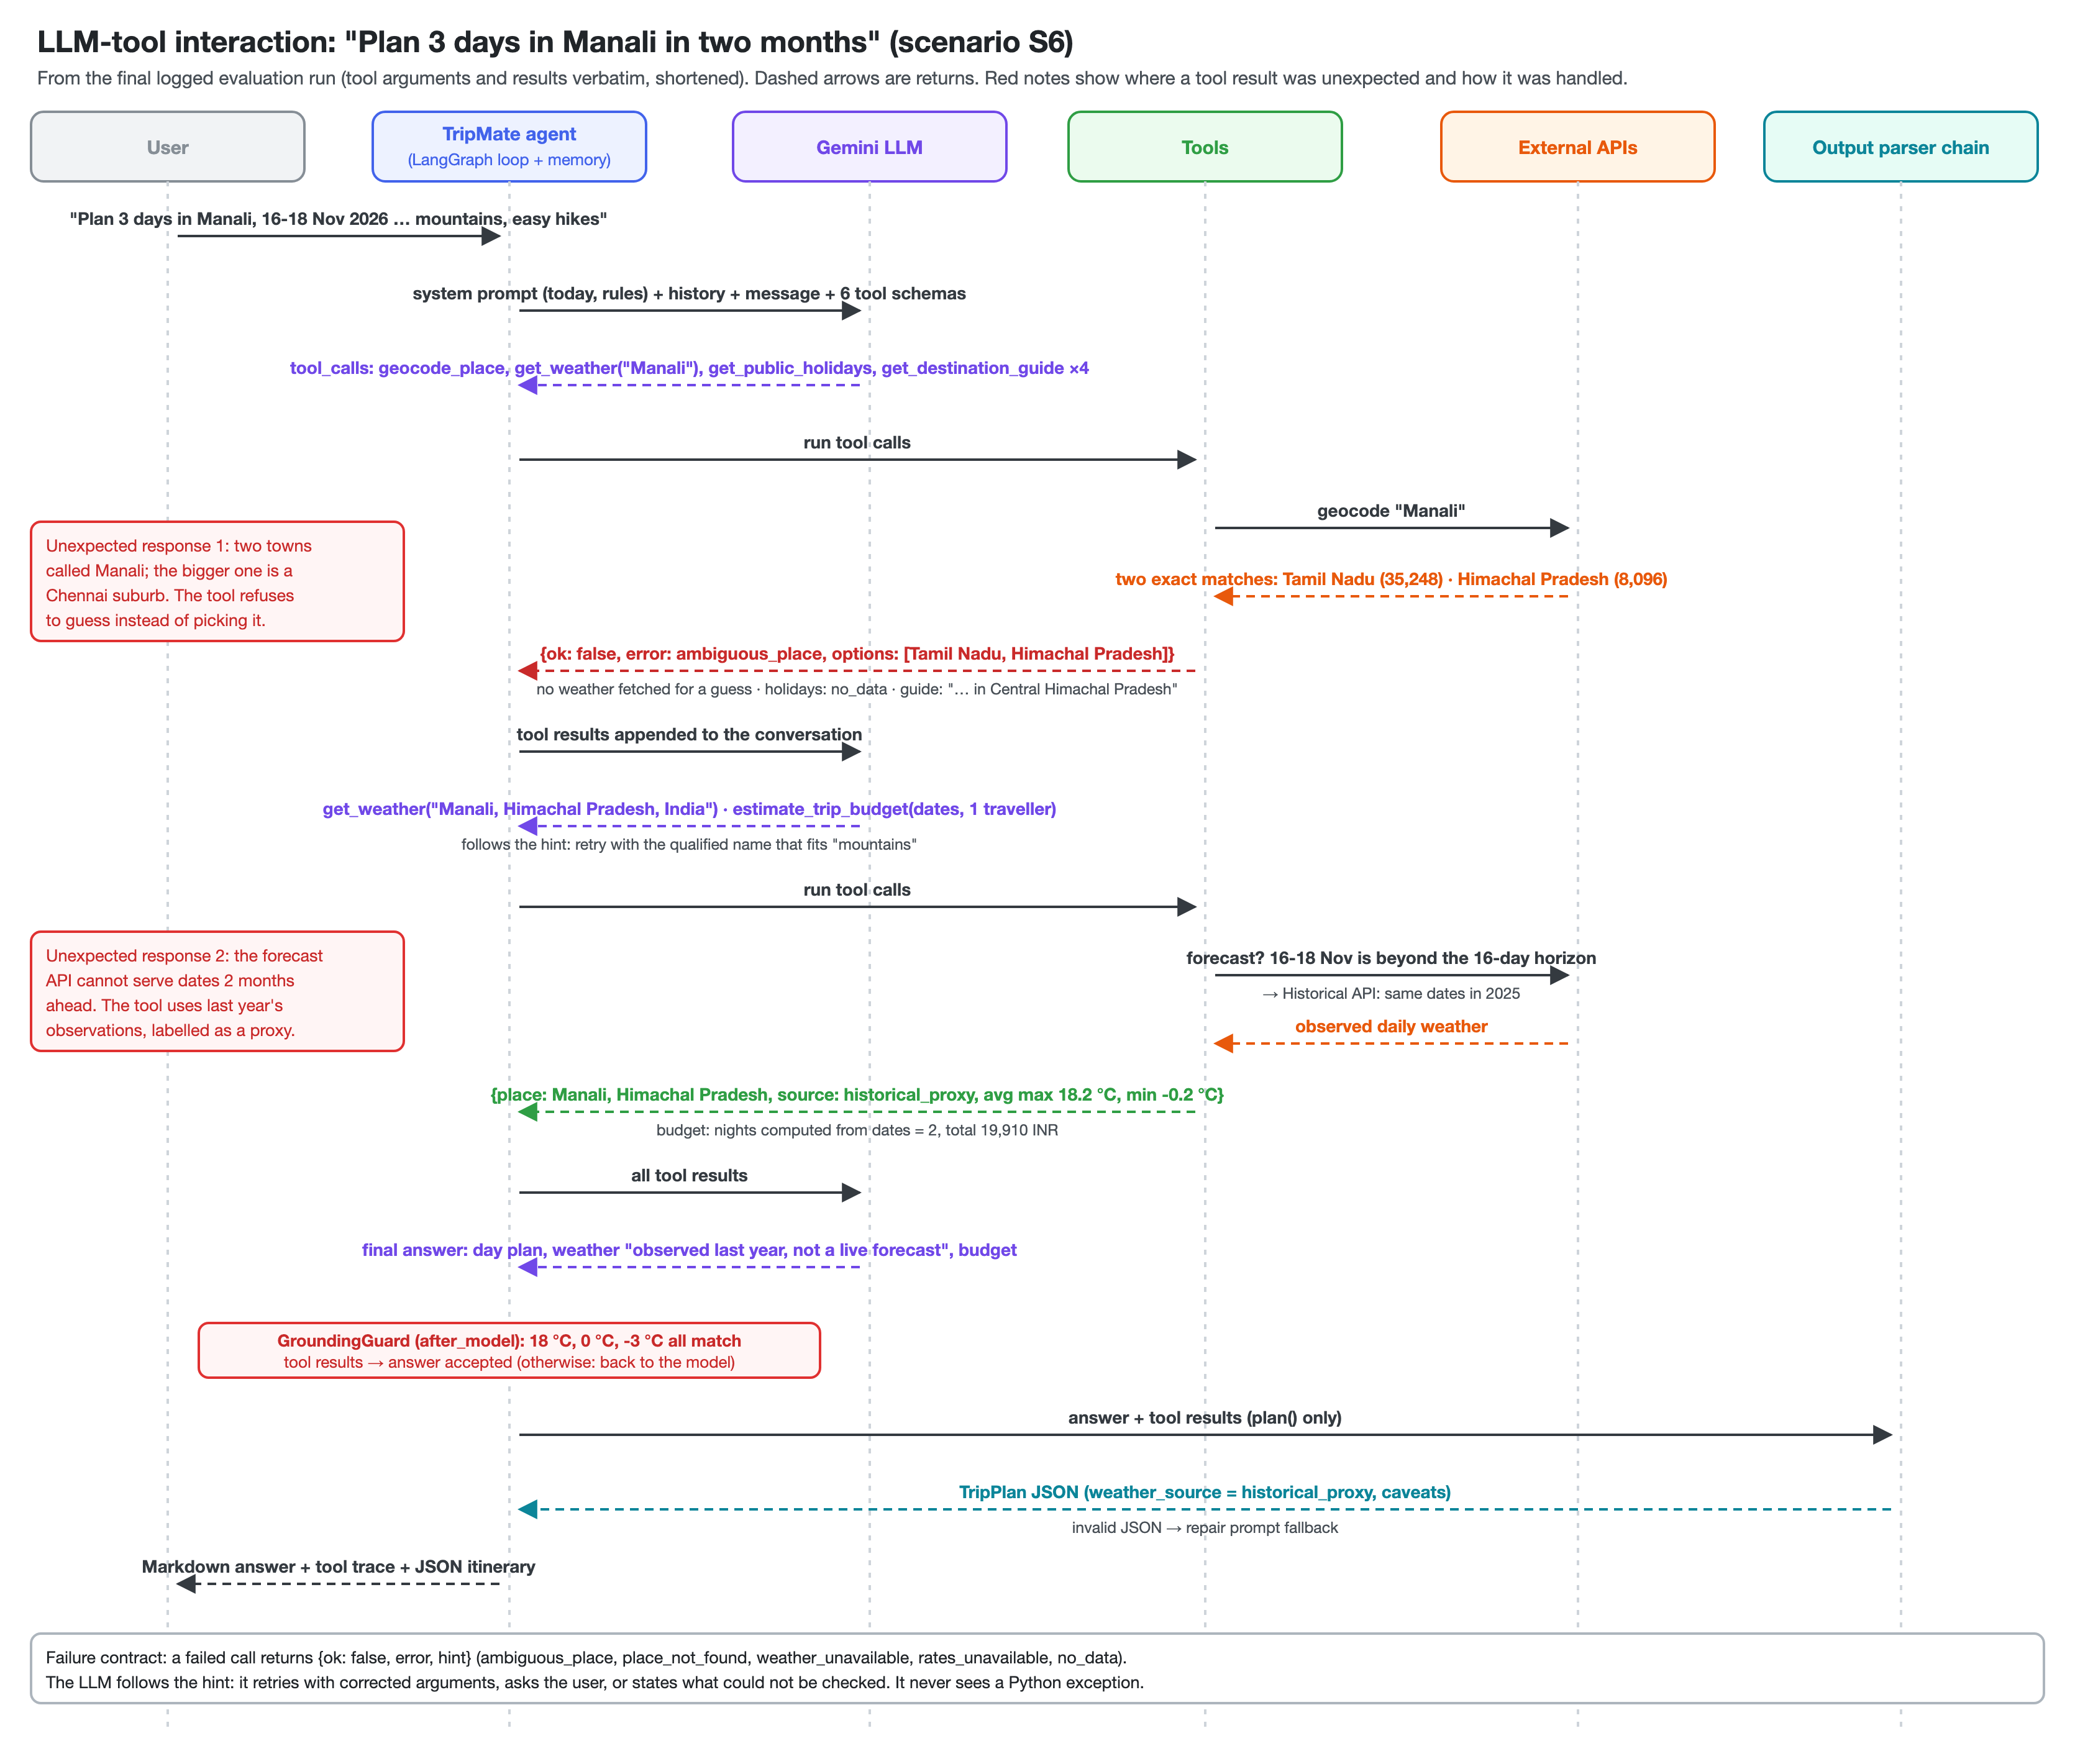

In [4]:
display(Image(filename="docs/llm_tool_sequence.png", width=1100))

| # | LangChain component | Where | Why it is needed |
|---|---|---|---|
| 1 | `PromptTemplate` / `ChatPromptTemplate` | `tripmate/prompts.py` | system prompt with today's date and grounding rules; structuring and repair prompts |
| 2 | Tools (`@tool`) + Agent (`create_agent`) | `tripmate/tools.py`, `tripmate/agent.py` | the LLM chooses and calls 6 tools |
| 3 | Memory (`InMemorySaver` checkpointer) | `tripmate/agent.py` | follow-up questions reuse the city, dates and results |
| 4 | Output parser (`PydanticOutputParser`) | `tripmate/agent.py`, `tripmate/schemas.py` | validated JSON itinerary |
| 5 | LCEL composition | `prompt \| llm \| parser`, `.with_fallbacks()`, `agent_turn \| structure` | repair invalid JSON, chain the agent and the parser |
| 6 | Middleware + rate limiter | custom `GroundingGuardMiddleware`, custom `FallbackMiddleware` with quota cooldown, call limits, `ToolErrorMiddleware`, `InMemoryRateLimiter` | no invented weather figures; robustness on the free Gemini tier |

## 4. LangChain components

### 4.1 The tools the LLM can call

In [5]:
for t in ALL_TOOLS:
    args = ", ".join(f"{k}: {v.get('type', 'any')}" for k, v in t.args.items())
    print(f"{t.name}({args})\n    {t.description.splitlines()[0]}\n")

geocode_place(place: string)
    Look up a city or town and return its country, region, coordinates and timezone. Use it to check that a destination exists or to disambiguate places with the same name.

get_weather(place: string, start_date: string, end_date: string)
    Daily weather for a place and date range (at most 16 days). Within the next 16 days this is a live forecast. For dates further ahead it returns the

convert_currency(amount: number, from_currency: string, to_currency: string)
    Convert an amount between currencies using today's reference exchange rate.

get_public_holidays(country_code: string, start_date: string, end_date: string)
    Public holidays in a country between two dates (useful for crowds, closures and prices).

get_destination_guide(place: string, section: string)
    Read one section of the Wikivoyage travel guide for a destination. Use it for attractions ("see"), activities ("do"), food ("eat"), transport ("get_around",

estimate_trip_budget(travellers

### 4.2 Calling the tools directly (no LLM)

Every tool returns JSON with an `ok` flag. Failures carry an `error` code and a `hint` telling the LLM what to do.

In [6]:
from tripmate.tools import get_weather, convert_currency, get_public_holidays, geocode_place, get_destination_guide

today = config.today()
d = lambda n: (today + dt.timedelta(days=n)).isoformat()

print("Live forecast (inside the 16-day horizon):")
show_json(get_weather.invoke({"place": "Jaipur, India", "start_date": d(4), "end_date": d(5)}))

Live forecast (inside the 16-day horizon):


{
  "ok": true,
  "place": "Jaipur, Rajasthan, India",
  "other_matches": [
    "Jaipur, Assam, India",
    "Jaipur, Assam, India"
  ],
  "data_source": "Open-Meteo Geocoding API + Open-Meteo Forecast API",
  "source": "forecast",
  "note": "Live forecast.",
  "days": [
    {
      "date": "2026-09-21",
      "conditions": "light drizzle",
      "temp_max_c": 32.5,
      "temp_min_c": 23.9,
      "precip_mm": 0.3,
      "rain_chance_pct": 16
    },
    {
      "date": "2026-09-22",
      "conditions": "clear sky",
      "temp_max_c": 34.2,
      "temp_min_c": 24.5,
      "precip_mm": 0.0,
      "rain_chance_pct": 16
    }
  ],
  "summary": {
    "avg_max_c": 33.4,
    "avg_min_c": 24.2,
    "wet_days": 0
  }
}


In [7]:
print("Beyond the horizon: last year's observations are returned and labelled as a proxy.")
out = get_weather.invoke({"place": "Manali, Himachal Pradesh", "start_date": d(60), "end_date": d(61)})
show_json({k: out[k] for k in ("ok", "place", "source", "note", "summary")})

Beyond the horizon: last year's observations are returned and labelled as a proxy.


{
  "ok": true,
  "place": "Manali, Himachal Pradesh, India",
  "source": "historical_proxy",
  "note": "These dates are beyond the 16-day forecast horizon, so these are the values observed on the same dates in 2025. Present them as typical conditions for the season, NOT as a forecast.",
  "summary": {
    "avg_max_c": 18.4,
    "avg_min_c": -0.8,
    "wet_days": 0
  }
}


In [8]:
print("AED is not in the ECB set, so the primary provider returns 404 and the fallback is used:")
show_json(convert_currency.invoke({"amount": 2000, "from_currency": "AED", "to_currency": "INR"}))

print("\nNager.Date answers HTTP 204 (empty) for India:")
show_json(get_public_holidays.invoke({"country_code": "IN", "start_date": d(10), "end_date": d(40)}))

print("\nUnknown place:")
show_json(geocode_place.invoke({"place": "Zorbania City"}))

print("\nAmbiguous name: the most populous 'Manali' is a Chennai suburb, not the hill station.")
show_json(geocode_place.invoke({"place": "Manali"}), limit=700)

print("\nFuzzy match rejected: the geocoder's only 'Panaji' results are a Guatemalan and a Gujarati village.")
show_json(geocode_place.invoke({"place": "Panaji"}))

AED is not in the ECB set, so the primary provider returns 404 and the fallback is used:


{
  "ok": true,
  "amount": 2000.0,
  "from_currency": "AED",
  "to_currency": "INR",
  "rate": 26.148863,
  "converted": 52297.73,
  "as_of": "Thu, 17 Sep 2026 00:02:31 +0000",
  "provider": "ExchangeRate-API open access",
  "note": "Primary provider could not price this pair (Frankfurter exchange rates (ECB) returned HTTP 404: {\"message\":\"not found\"}); used the fallback provider."
}

Nager.Date answers HTTP 204 (empty) for India:
{
  "ok": false,
  "error": "no_data",
  "message": "The holiday service returned an empty response (HTTP 204 No Content) for IN in 2026. Its coverage of this country is missing; this does NOT mean there are no holidays.",
  "hint": "Tell the user verified holiday data is unavailable for this country. Well-known festivals may be mentioned only if clearly labelled as unverified general knowledge."
}

Unknown place:
{
  "ok": false,
  "error": "place_not_found",
  "message": "No town called 'Zorbania City' was found by the geocoder.",
  "hint": "If the des

In [9]:
guide = get_destination_guide.invoke({"place": "Jaipur", "section": "see"})
print(guide["page"], "/", guide["section"], "| truncated:", guide["truncated"], "|", guide["license"])
print(guide["text"][:700], "...")

Jaipur / See | truncated: True | Wikivoyage, CC BY-SA 4.0
Amber Fort:
1 Amber Fort (अंबेर क़िला Amber Qilā) (11 km North of central Jaipur, local bus #5 from Hawa Mahal or New Gate), ☏ +91 14 1253 0293. 8AM-6PM. This massive fort-palace complex built in hybrid Hindu-Muslim style dates back to Raja Man Singh and was the royal palace of the Kachwahas from c. 1600-1727. It's one of six UNESCO World Heritage forts in Rajasthan. The name has nothing to do with the rather pretty pastel yellow colour; instead, the fort is named after the area of Amber, in turn named after the goddess Amba. ₹100/20 for Indian adult/student and ₹500/100 for foreign adult/student. Included in the Composite Ticket. There is a special evening viewing from 6:30-9AM, ₹100 for al ...


### 4.3 Prompt template (rendered on every model call)

In [10]:
print(AGENT_SYSTEM_PROMPT.format(today=today.isoformat(), weekday=today.strftime("%A"), home_currency="INR"))

You are TripMate, a careful travel-planning assistant. Today is 2026-09-17 (Thursday).

How to work
1. Resolve relative dates ("next weekend", "in two months") against today and state the exact dates you assumed.
   If the user gives no dates for a plan, assume the trip starts one week from today and say so.
2. Facts about weather, exchange rates, public holidays and attractions MUST come from your tools, not from memory.
   Call every tool you need; independent tools can be called together.
3. Place lookups can match the wrong town with the same name. Check the "place" field a tool returns. If its
   region or country is not what the user means, call the tool again with a qualified name such as
   "Paris, France". States, regions and islands are not towns: use their main town (e.g. "Hilo, Hawaii").
4. Every tool returns JSON with "ok". When "ok" is false, read "error" and "hint" and follow the hint: retry once
   with corrected arguments if it says so, otherwise tell the user plainly 

### 4.4 Output parser: format instructions derived from the `TripPlan` Pydantic schema

In [11]:
bot = TripMate()
print(bot.parser.get_format_instructions()[:900], "...")

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"$defs": {"BudgetLine": {"properties": {"category": {"title": "Category", "type": "string"}, "amount": {"title": "Amount", "type": "number"}}, "required": ["category", "amount"], "title": "BudgetLine", "type": "object"}, "DayPlan": {"properties": {"day": {"description": "Day number starting at 1", "title": "Day", "type": "integer"}, "date": {"anyOf": [{"type": "string"}, {"type": "null"}], "default": null, "description": "YYYY-MM-DD if known",  ...


## 5. Agent demo

> The free Gemini tier allows only a few requests per minute, so a shared `InMemoryRateLimiter` spaces the calls
> out. A full trip plan takes 1-2 minutes.

### 5.1 A quick question: one tool call, answer grounded in the forecast

In [12]:
turn = bot.chat("Will it rain in Tokyo this weekend?")
display(Markdown(turn_to_markdown(turn)))

**User:** Will it rain in Tokyo this weekend?

**Tool calls:**
- `1. get_weather({"end_date": "2026-09-20", "start_date": "2026-09-19", "place": "Tokyo"}) -> ok`

**TripMate:**

Yes, it is expected to rain in Tokyo this weekend (Saturday, September 19 to Sunday, September 20, 2026). 

According to the live forecast:
* **Saturday, Sep 19:** Light drizzle with a 78% chance of rain (approx. 0.8 mm of precipitation).
* **Sunday, Sep 20:** Light rain with a 97% chance of rain (approx. 11.2 mm of precipitation).

*2 model call(s), 4483 tokens, 47.03s*

### 5.2 Memory: the follow-up does not repeat the dates

In [13]:
turn = bot.chat("And what about Osaka on the same days?")
display(Markdown(turn_to_markdown(turn)))
print("Messages stored in this thread:", len(bot.messages))

**User:** And what about Osaka on the same days?

**Tool calls:**
- `1. get_weather({"start_date": "2026-09-19", "end_date": "2026-09-20", "place": "Osaka"}) -> ok`

**TripMate:**

No, it is not expected to rain in Osaka this weekend (Saturday, September 19 to Sunday, September 20, 2026). 

According to the live forecast:
* **Saturday, Sep 19:** Overcast, with a low rain chance of 30% and 0 mm of precipitation.
* **Sunday, Sep 20:** Overcast, with a low rain chance of 25% and 0 mm of precipitation.

*2 model call(s), 5290 tokens, 30.09s*

Messages stored in this thread: 8


### 5.3 Full plan with a structured JSON itinerary (agent → LCEL parsing chain)

In [14]:
planner = TripMate()
start = today + dt.timedelta(days=5)
turn = planner.plan(f"Plan a 2-day trip to Udaipur for one person from {start:%d %B} to "
                    f"{start + dt.timedelta(days=1):%d %B}. I like palaces, lakes and street food. Budget in INR.")
display(Markdown(turn_to_markdown(turn)))

**User:** Plan a 2-day trip to Udaipur for one person from 22 September to 23 September. I like palaces, lakes and street food. Budget in INR.

**Tool calls:**
- `1. geocode_place({"place": "Udaipur"}) -> ok`
- `2. get_weather({"end_date": "2026-09-23", "start_date": "2026-09-22", "place": "Udaipur"}) -> ok`
- `3. get_public_holidays({"start_date": "2026-09-22", "end_date": "2026-09-23", "country_code": "IN"}) -> FAILED: no_data`
- `4. get_destination_guide({"place": "Udaipur", "section": "see"}) -> ok`
- `5. get_destination_guide({"section": "eat", "place": "Udaipur"}) -> ok`
- `6. estimate_trip_budget({"start_date": "2026-09-22", "local_transport_per_day": 400, "accommodation_per_night": 2500, "travellers": 1, "activities_per_person": `

**TripMate:**

**Udaipur: Palaces, Lakes, and Street Food (22–23 September 2026)**

A 2-day getaway for 1 person exploring the majestic palaces, serene lakes, and renowned street food of the "Venice of the East."

### Weather
- **22 Sep:** ~23.6°C to 30°C, scattered thunderstorms (chance of rain ~36%).
- **23 Sep:** ~23.2°C to 30.4°C, partly cloudy.
- *Source:* Live forecast (Open-Meteo).

---

### Day-by-Day Itinerary

#### Day 1: Royal Heritage & Sunset Lake Views (22 September)
- **Morning:** Arrive in Udaipur, check in, and head straight to the magnificent **Udaipur City Palace** towering over Lake Pichola. Explore its grand courtyards, mirror work, and museums (such as the Durbar Hall and Amar Vilas).
- **Afternoon:** Take a relaxing late-lunch break in the Old City, sampling local specialties like *pyaz kachori* and *mirchi bada* from popular street stalls or small eateries near Gangaur Ghat.
- **Evening:** Walk down to Bansi Ghat or the City Palace jetty for a sunset boat ride on **Lake Pichola**, passing Jag Mandir and the Lake Palace. Conclude with a dinner of Rajasthani thali or street-side chaat near Delhi Gate.

#### Day 2: Lakeside Charm & Culinary Trails (23 September)
- **Morning:** Visit **Jagdish Temple** in the heart of the Old City, then stroll along the scenic lakeside promenades (Gangaur Ghat and Ambrai Ghat) for striking angles of the palaces across the water.
- **Afternoon:** Explore local markets or enjoy a quiet pastry and coffee at a heritage bakery near Gangaur Ghat. Hunt down iconic Rajasthani street treats like *dal baati churma* or fresh *gatte ki sabzi*.
- **Evening:** Wrap up your trip with a peaceful walk by Fatehsagar Lake before departing.

---

### Estimated Budget (1 Traveller, in INR)

| Expense Category | Cost (INR) |
| :--- | :--- |
| Intercity Travel (Return) | ₹2,000 |
| Accommodation (1 Night) | ₹2,500 |
| Food & Drink (₹600 / day) | ₹1,200 |
| Activities & Entry Tickets | ₹1,200 |
| Local Transport (₹400 / day) | ₹800 |
| Contingency Buffer (~10%) | ₹770 |
| **Total Estimated Budget** | **₹8,470** |

---

### Practical Tips
- **Rain Gear:** Since September falls at the tail end of the monsoon with a chance of thunderstorms on Day 1, pack a lightweight umbrella or rain jacket.
- **Footwear:** Comfortable walking shoes are essential for navigating the sloping cobblestone lanes of the Old City and the steep stairs inside the palaces and rooftop cafes.
- **Getting Around:** Auto-rickshaws and cycle-rickshaws are the most efficient ways to get around the narrow lanes of the Old City. Agree on a fare beforehand.

***

*Sources & caveats: Geocoding and live weather forecasts via Open-Meteo; destination highlights and food tips via Wikivoyage (CC BY-SA 4.0); public holiday coverage unavailable for India in 2026; budget amounts are realistic estimates computed by TripMate.*

*3 model call(s), 13154 tokens, 47.04s*

**Structured itinerary (PydanticOutputParser):**

```json
{
  "destination": "Udaipur",
  "country": "India",
  "start_date": "2026-09-22",
  "end_date": "2026-09-23",
  "travellers": 1,
  "interests": [
    "palaces",
    "lakes",
    "street food"
  ],
  "weather_source": "forecast",
  "weather_summary": "22 Sep: ~23.6°C to 30°C, scattered thunderstorms (chance of rain ~36%). 23 Sep: ~23.2°C to 30.4°C, partly cloudy.",
  "days": [
    {
      "day": 1,
      "date": "2026-09-22",
      "title": "Royal Heritage & Sunset Lake Views",
      "morning": "Arrive in Udaipur, check in, and head straight to the magnificent Udaipur City Palace towering over Lake Pichola. Explore its grand courtyards, mirror work, and museums (such as the Durbar Hall and Amar Vilas).",
      "afternoon": "Take a relaxing late-lunch break in the Old City, sampling local specialties like pyaz kachori and mirchi bada from popular street stalls or small eateries near Gangaur Ghat.",
      "evening": "Walk down to Bansi Ghat or the City Palace jetty for a sunset boat ride on Lake Pichola, passing Jag Mandir and the Lake Palace. Conclude with a dinner of Rajasthani thali or street-side chaat near Delhi Gate.",
      "weather": "~23.6°C to 30°C, scattered thunderstorms (chance of rain ~36%)."
    },
    {
      "day": 2,
      "date": "2026-09-23",
      "title": "Lakeside Charm & Culinary Trails",
      "morning": "Visit Jagdish Temple in the heart of the Old City, then stroll along the scenic lakeside promenades (Gangaur Ghat and Ambrai Ghat) for striking angles of the palaces across the water.",
      "afternoon": "Explore local markets or enjoy a quiet pastry and coffee at a heritage bakery near Gangaur Ghat. Hunt down iconic Rajasthani street treats like dal baati churma or fresh gatte ki sabzi.",
      "evening": "Wrap up your trip with a peaceful walk by Fatehsagar Lake before departing.",
      "weather": "~23.2°C to 30.4°C, partly cloudy."
    }
  ],
  "budget_currency": "INR",
  "budget_lines": [
    {
      "category": "Intercity Travel (Return)",
      "amount": 2000.0
    },
    {
      "category": "Accommodation (1 Night)",
      "amount": 2500.0
    },
    {
      "category": "Food & Drink (₹600 / day)",
      "amount": 1200.0
    },
    {
      "category": "Activities & Entry Tickets",
      "amount": 1200.0
    },
    {
      "category": "Local Transport (₹400 / day)",
      "amount": 800.0
    },
    {
      "category": "Contingency Buffer (~10%)",
      "amount": 770.0
    }
  ],
  "budget_total": 8470.0,
  "tips": [
    "Rain Gear: Since September falls at the tail end of the monsoon with a chance of thunderstorms on Day 1, pack a lightweight umbrella or rain jacket.",
    "Footwear: Comfortable walking shoes are essential for navigating the sloping cobblestone lanes of the Old City and the steep stairs inside the palaces and rooftop cafes.",
    "Getting Around: Auto-rickshaws and cycle-rickshaws are the most efficient ways to get around the narrow lanes of the Old City. Agree on a fare beforehand."
  ],
  "caveats": [
    "Public holiday coverage unavailable for India in 2026.",
    "Budget amounts are realistic estimates computed by TripMate."
  ],
  "sources": [
    "Open-Meteo Geocoding API",
    "Open-Meteo Forecast API",
    "Wikivoyage (MediaWiki API)",
    "local calculation"
  ]
}
```

In [15]:
if turn.plan:
    display(Markdown(plan_to_markdown(turn.plan)))
else:
    print("Structuring failed:", turn.plan_error)

## Udaipur, India
**When:** 2026-09-22 to 2026-09-23  |  **Travellers:** 1  |  **Weather source:** `forecast`

**Weather:** 22 Sep: ~23.6°C to 30°C, scattered thunderstorms (chance of rain ~36%). 23 Sep: ~23.2°C to 30.4°C, partly cloudy.

### Day 1 (2026-09-22): Royal Heritage & Sunset Lake Views
- **Morning:** Arrive in Udaipur, check in, and head straight to the magnificent Udaipur City Palace towering over Lake Pichola. Explore its grand courtyards, mirror work, and museums (such as the Durbar Hall and Amar Vilas).
- **Afternoon:** Take a relaxing late-lunch break in the Old City, sampling local specialties like pyaz kachori and mirchi bada from popular street stalls or small eateries near Gangaur Ghat.
- **Evening:** Walk down to Bansi Ghat or the City Palace jetty for a sunset boat ride on Lake Pichola, passing Jag Mandir and the Lake Palace. Conclude with a dinner of Rajasthani thali or street-side chaat near Delhi Gate.
- *Weather:* ~23.6°C to 30°C, scattered thunderstorms (chance of rain ~36%).

### Day 2 (2026-09-23): Lakeside Charm & Culinary Trails
- **Morning:** Visit Jagdish Temple in the heart of the Old City, then stroll along the scenic lakeside promenades (Gangaur Ghat and Ambrai Ghat) for striking angles of the palaces across the water.
- **Afternoon:** Explore local markets or enjoy a quiet pastry and coffee at a heritage bakery near Gangaur Ghat. Hunt down iconic Rajasthani street treats like dal baati churma or fresh gatte ki sabzi.
- **Evening:** Wrap up your trip with a peaceful walk by Fatehsagar Lake before departing.
- *Weather:* ~23.2°C to 30.4°C, partly cloudy.

| Budget item | Amount |
|---|---:|
| Intercity Travel (Return) | 2,000 INR |
| Accommodation (1 Night) | 2,500 INR |
| Food & Drink (₹600 / day) | 1,200 INR |
| Activities & Entry Tickets | 1,200 INR |
| Local Transport (₹400 / day) | 800 INR |
| Contingency Buffer (~10%) | 770 INR |
| **Total** | **8,470 INR** |

**Tips:**
- Rain Gear: Since September falls at the tail end of the monsoon with a chance of thunderstorms on Day 1, pack a lightweight umbrella or rain jacket.
- Footwear: Comfortable walking shoes are essential for navigating the sloping cobblestone lanes of the Old City and the steep stairs inside the palaces and rooftop cafes.
- Getting Around: Auto-rickshaws and cycle-rickshaws are the most efficient ways to get around the narrow lanes of the Old City. Agree on a fare beforehand.

**Caveats:**
- Public holiday coverage unavailable for India in 2026.
- Budget amounts are realistic estimates computed by TripMate.

**Sources:**
- Open-Meteo Geocoding API
- Open-Meteo Forecast API
- Wikivoyage (MediaWiki API)
- local calculation

## 6. Failure handling

A tool never raises into the agent. It returns `{"ok": false, "error": ..., "hint": ...}` and the system prompt
tells the LLM to follow the hint: retry with corrected arguments, ask the user, or say what could not be checked.

| Failure | Detected by | Handling |
|---|---|---|
| Service down / timeout / HTTP 5xx | `net.get_json` (3 attempts) | `ToolFailure` → `{ok: false, hint}`; weather falls back from forecast to history |
| HTTP 429 rate limit | `Retry-After` header | wait up to 25 s and retry, then report `rate_limited` |
| Dates beyond forecast horizon | `get_weather` date check | same dates last year, labelled `historical_proxy` |
| Currency not supported (AED) | Frankfurter HTTP 404 | fallback provider ExchangeRate-API, noted in result |
| Empty body (HTTP 204, India holidays) | `get_public_holidays` | `no_data`: "this does NOT mean there are no holidays" |
| Unknown place | geocoder | `place_not_found` listing the closest names |
| Same-name towns ("Manali": Tamil Nadu 35k vs Himachal Pradesh 8k) | `get_weather` | `ambiguous_place` with options; the LLM retries with a qualified name or asks |
| Budget nights inconsistent with trip dates | `estimate_trip_budget` | nights computed from the dates; mismatch noted |
| Fuzzy geocoder match ("Panaji" → a village in Gujarat) | `_geocode` | only exact names, or towns of ≥ 15,000 people; otherwise `place_not_found` listing the closest names |
| Tool bug (exception) | `ToolErrorMiddleware` | converted to an error `ToolMessage` |
| Invalid JSON itinerary | `PydanticOutputParser` | `.with_fallbacks()` repair prompt, else `plan_error` |
| Model states weather no tool returned | `GroundingGuardMiddleware` | sends the model back once to fetch or remove the figures; warns if it insists |
| Gemini overloaded (HTTP 503) | `ModelSelector` | retries after 5 s and 20 s |
| Gemini quota exhausted (HTTP 429) | `FallbackMiddleware` / `ModelSelector` | switches to `gemini-3.5-flash-lite`, skips the exhausted model for 10 min |

### 6.1 Live demo: both weather services forced offline

In [16]:
outage_bot = TripMate()
with net.outage("forecast", "archive"):
    turn = outage_bot.chat("What's the weather going to be like in Goa for the next three days?")
display(Markdown(turn_to_markdown(turn, include_outputs=True)))

**User:** What's the weather going to be like in Goa for the next three days?

**Tool calls:**
- `1. geocode_place({"place": "Goa"}) -> ok`
- `2. get_weather({"place": "Goa", "end_date": "2026-09-19", "start_date": "2026-09-17"}) -> FAILED: weather_unavailable`
- `3. geocode_place({"place": "Goa, India"}) -> FAILED: place_not_found`
- `4. geocode_place({"place": "Panaji"}) -> FAILED: place_not_found`
- `5. geocode_place({"place": "Panaji, India"}) -> FAILED: place_not_found`

<details><summary>geocode_place output</summary>

```json
{"ok": true, "query": "Goa", "source": "Open-Meteo Geocoding API", "matches": [{"label": "Goa, Bicol Region, Philippines", "country_code": "PH", "latitude": 13.6978, "longitude": 123.4892, "timezone": "Asia/Manila", "population": 20936}, {"label": "Genoa, Liguria, Italy", "country_code": "IT", "latitude": 44.40478, "longitude": 8.94439, "timezone": "Europe/Rome", "population": 580097}, {"label": "Goá, Galicia, Spain", "country_code": "ES", "latitude": 43.26667, "longitude": -7.51667, "timezone": "Europe/Madrid", "population": null}]}
```
</details>

<details><summary>get_weather output</summary>

```json
{"ok": false, "error": "weather_unavailable", "message": "No weather data could be retrieved (forecast: Open-Meteo Forecast API is unreachable (simulated outage).; history: Open-Meteo Historical Weather API is unreachable (simulated outage).).", "hint": "Tell the user the weather could not be checked. Do not state temperatures or rain figures; general seasonal advice is fine only if labelled as general knowledge."}
```
</details>

<details><summary>geocode_place output</summary>

```json
{"ok": false, "error": "place_not_found", "message": "No town called 'Goa, India' was found by the geocoder. Closest names: Genoa, Liguria, Italy; Goa, Bicol Region, Philippines; Goá, Galicia, Spain.", "hint": "If the destination is a state, region or island, retry once with its main town qualified by the region (for example 'Hilo, Hawaii'). Otherwise ask the user to check the spelling or name a nearby town. Never guess weather for an unknown place."}
```
</details>

<details><summary>geocode_place output</summary>

```json
{"ok": false, "error": "place_not_found", "message": "No town called 'Panaji' was found by the geocoder. Closest names: Panajijay, Chimaltenango, Guatemala; Panāji Muwara, Gujarat, India.", "hint": "If the destination is a state, region or island, retry once with its main town qualified by the region (for example 'Hilo, Hawaii'). Otherwise ask the user to check the spelling or name a nearby town. Never guess weather for an unknown place."}
```
</details>

<details><summary>geocode_place output</summary>

```json
{"ok": false, "error": "place_not_found", "message": "No town called 'Panaji, India' was found by the geocoder. Closest names: Panāji Muwara, Gujarat, India.", "hint": "If the destination is a state, region or island, retry once with its main town qualified by the region (for example 'Hilo, Hawaii'). Otherwise ask the user to check the spelling or name a nearby town. Never guess weather for an unknown place."}
```
</details>

**TripMate:**

I am unable to check the current live weather forecast for Goa right now due to a temporary service interruption with the weather data provider. 

Generally speaking, September falls during the southwest monsoon season in Goa, which typically brings warm temperatures, high humidity, and frequent rain showers or thunderstorms. If you are planning outdoor activities, it is best to keep an umbrella handy and check local updates before heading out.

*5 model call(s), 11488 tokens, 73.34s*

## 7. Testing and evaluation

### 7.1 Offline unit tests
41 pytest tests mock every HTTP call and replace Gemini with a scripted fake chat model. They cover the tool logic
and failure paths as well as the LangChain wiring (tool loop, memory, parser, repair fallback).

In [17]:
import subprocess
result = subprocess.run([sys.executable, "-m", "pytest", "--color=no"], capture_output=True, text=True,
                        env={**os.environ, "GEMINI_API_KEY": ""})
print(result.stdout[-1500:])

.........................................                                [100%]
41 passed in 0.40s



### 7.2 Live scenario evaluation (10 scenarios, real Gemini + real APIs)
Run with `python -m evaluation.run_evaluation`. Each scenario has automatic checks (tools called, tool results,
answer content, JSON validity) plus a **numeric grounding** heuristic: the share of temperatures, percentages and
money amounts in the answer that match a tool argument, tool result or the user's message.

In [18]:
results = json.load(open("results/test_results.json"))
rows = ["| ID | Scenario | Category | Result | Checks | Tools (failed) | Model calls | Time (s) | Grounding |",
        "|---|---|---|---|---|---|---|---|---|"]
for r in results["scenarios"]:
    m, g = r["metrics"], r["metrics"]["numeric_grounding"]
    passed = sum(c["passed"] for c in r["checks"])
    rows.append(f"| {r['id']} | {r['title']} | {r['category']} | {'PASS' if r['passed'] else 'FAIL'} | "
                f"{passed}/{len(r['checks'])} | {m['tool_calls']} ({m['failed_tool_calls']}) | {m['model_calls']} | "
                f"{m['seconds']} | {str(g['grounded']) + '/' + str(g['claims']) if g['claims'] else 'n/a'} |")
models = sorted({m for r in results["scenarios"] for m in r["metrics"]["models"]})
print("Run:", results["meta"]["run_at"], "| configured model:", results["meta"]["model"], "| models that answered:", models)
display(Markdown("\n".join(rows)))

Run: 2026-09-17 11:41 | configured model: gemini-3.5-flash | models that answered: ['gemini-3.5-flash-lite']


| ID | Scenario | Category | Result | Checks | Tools (failed) | Model calls | Time (s) | Grounding |
|---|---|---|---|---|---|---|---|---|
| S1 | Full trip plan (Jaipur) | core | PASS | 7/7 | 6 (1) | 3 | 74.5 | 11/12 |
| S2 | Quick weather question (Tokyo weekend) | core | PASS | 3/3 | 2 (0) | 2 | 34.6 | 3/3 |
| S3 | Currency conversion (USD to EUR and INR) | core | PASS | 4/4 | 2 (0) | 2 | 20.4 | 5/5 |
| S4 | Multi-turn memory (Udaipur) | memory | PASS | 6/6 | 4 (0) | 5 | 80.1 | 17/18 |
| S5 | Unknown destination (tool returns place_not_found) | failure | PASS | 4/4 | 1 (1) | 2 | 30.6 | n/a |
| S6 | Dates beyond the forecast horizon (Manali in two months) | failure | PASS | 5/5 | 9 (2) | 4 | 62.5 | 14/14 |
| S7 | Unsupported currency, fallback provider (AED to INR) | failure | PASS | 2/2 | 1 (0) | 2 | 28.0 | 3/3 |
| S8 | Empty API response (India public holidays) | failure | PASS | 3/3 | 3 (2) | 4 | 60.6 | n/a |
| S9 | Weather service outage (simulated) | failure | PASS | 3/3 | 4 (3) | 4 | 59.6 | n/a |
| S10 | Off-topic request / prompt injection | guardrail | PASS | 3/3 | 0 (0) | 1 | 14.8 | n/a |

In [19]:
for r in results["scenarios"]:
    failed = [c for c in r["checks"] if not c["passed"]]
    if failed:
        print(r["id"], r["title"])
        for c in failed:
            print("   FAILED:", c["check"], "->", c["detail"][:200])
print("Full transcripts: results/sample_outputs/<ID>.md")

Full transcripts: results/sample_outputs/<ID>.md


## 8. Limitations and improvements

**Limitations**
* **Costs are LLM estimates.** Only the arithmetic is exact; hotel, food and ticket prices are not looked up.
* **Place disambiguation is heuristic.** The geocoder ranks by name and population ("Manali" → Tamil Nadu); the
  agent must notice and retry with a qualified name. The geocoder also has no entry for regions such as "Goa".
* **Guide content is general.** Wikivoyage sections are clipped to 2,500 characters, big cities split content into
  district pages, and opening hours or prices in the text may be out of date.
* **Specific details can still come from the model's memory** (train times, restaurant names). The numeric grounding
  check only covers temperatures, percentages and money amounts.
* **Latency and quota.** Free-tier limits are tiny (20 requests/day on gemini-3.5-flash), so the client spaces calls
  out and a full plan takes 1-2 minutes.
* **Memory is in-process.** Restarting the app loses conversations.

**Proposed improvements**
* Add a hotel/transport price API (e.g. Amadeus self-service) so budgets are grounded too.
* Ask the user to choose when the geocoder returns several strong matches, instead of relying on the LLM to notice.
* Persist memory with a SQLite/Postgres checkpointer and add `SummarizationMiddleware` for long chats.
* Add an LLM-as-judge groundedness check over all factual claims, not only numbers.
* Stream tokens and tool progress to the UI to reduce perceived latency.